# Monocle Bone Marrow — λ_vf Sweep Plotting

Data extracted from run `monocle_bone_marrow_vf_sweep_20260524_130012`.  
Seeds 1–5 all complete.  
λ_lap fixed at 0.  
Epochs logged every 10 steps; epoch 140 is used as proxy for epoch 150 (final).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# λ_vf values — np.logspace(-2, 4.0, 12)
LAMBDA_VFS = np.logspace(-2, 4.0, 12)
print('lambda_vf values:', np.round(LAMBDA_VFS, 4))

lambda_vf values: [1.0000000e-02 3.5100000e-02 1.2330000e-01 4.3290000e-01 1.5199000e+00
 5.3367000e+00 1.8738200e+01 6.5793300e+01 2.3101300e+02 8.1113080e+02
 2.8480359e+03 1.0000000e+04]


In [2]:
# ---------------------------------------------------------------------------
# Raw data: r values logged every 10 epochs (i=0,10,...,140)
# Shape: [seed, lambda_idx, epoch_idx]  where epoch_idx ∈ {0,1,...,14} → epochs 0,10,...,140
# NaN = run not reached / log cut off
# Run: monocle_bone_marrow_vf_sweep_20260524_130012  |  Seeds 1–5  |  λ_lap=0
# ---------------------------------------------------------------------------

EPOCHS_LOGGED = list(range(0, 141, 10))  # 0, 10, ..., 140

# Each row = one lambda_vf, each column = one logged epoch (0,10,...,140)
seed1 = np.array([
    # lv=1e-2
    [0.235, 0.527, 0.585, 0.598, 0.605, 0.603, 0.595, 0.595, 0.590, 0.589, 0.590, 0.591, 0.592, 0.601, 0.598],
    # lv=3.511e-2
    [0.205, 0.133, 0.189, 0.158, 0.144, 0.171, 0.178, 0.172, 0.201, 0.243, 0.233, 0.240, 0.219, 0.237, 0.265],
    # lv=1.233e-1
    [0.401, 0.250, 0.299, 0.320, 0.330, 0.330, 0.336, 0.342, 0.349, 0.356, 0.362, 0.369, 0.376, 0.382, 0.386],
    # lv=4.329e-1
    [0.208, 0.748, 0.564, 0.550, 0.543, 0.541, 0.540, 0.539, 0.539, 0.539, 0.538, 0.538, 0.536, 0.533, 0.532],
    # lv=1.520
    [0.076, 0.215, 0.049, 0.002, -0.023, -0.027, -0.023, -0.007, 0.009, 0.024, 0.040, 0.074, 0.115, 0.157, 0.185],
    # lv=5.337
    [0.332, 0.438, 0.269, 0.463, 0.677, 0.674, 0.713, 0.718, 0.694, 0.716, 0.713, 0.714, 0.711, 0.346, 0.718],
    # lv=18.74
    [0.383, 0.461, 0.529, 0.487, 0.460, 0.471, 0.383, 0.221, 0.304, 0.318, 0.342, 0.394, 0.385, 0.404, 0.442],
    # lv=65.79
    [0.215, -0.005, 0.041, 0.054, 0.046, 0.034, 0.021, 0.005, -0.009, -0.020, -0.026, -0.032, -0.015, 0.180, 0.097],
    # lv=231.0
    [0.641, -0.094, -0.112, -0.344, -0.166, -0.157, -0.088, 0.159, 0.558, 0.609, 0.574, 0.561, 0.573, 0.570, 0.567],
    # lv=811.1
    [0.355, 0.232, 0.270, 0.336, 0.350, 0.327, 0.310, 0.231, 0.089, -0.175, -0.284, -0.298, -0.270, -0.254, -0.245],
    # lv=2848
    [0.426, 0.429, 0.177, 0.175, 0.329, 0.446, 0.597, 0.570, 0.587, 0.577, 0.548, 0.531, 0.605, 0.552, 0.596],
    # lv=1e4
    [0.457, 0.429, 0.323, 0.233, 0.706, 0.657, 0.558, 0.579, 0.522, 0.566, 0.579, 0.579, 0.579, 0.577, 0.579],
])

seed2 = np.array([
    # lv=1e-2
    [0.604, 0.500, 0.365, 0.318, 0.266, 0.345, 0.331, 0.274, 0.370, 0.387, 0.507, 0.487, 0.513, 0.609, 0.593],
    # lv=3.511e-2
    [0.484, 0.461, 0.383, 0.343, 0.331, 0.328, 0.330, 0.327, 0.318, 0.338, 0.333, 0.363, 0.372, 0.396, 0.419],
    # lv=1.233e-1
    [0.322, 0.029, 0.179, -0.101, 0.039, -0.111, -0.102, -0.119, -0.126, -0.154, -0.168, -0.169, -0.195, -0.186, -0.197],
    # lv=4.329e-1
    [0.284, 0.463, 0.478, 0.559, 0.400, 0.288, 0.408, 0.445, 0.451, 0.426, 0.418, 0.413, 0.401, 0.396, 0.388],
    # lv=1.520
    [0.311, 0.371, 0.521, 0.509, 0.498, 0.691, 0.675, 0.519, 0.383, 0.636, 0.548, 0.479, 0.457, 0.396, 0.456],
    # lv=5.337
    [0.226, 0.541, 0.542, 0.492, 0.433, 0.413, 0.429, 0.428, 0.445, 0.493, 0.501, 0.544, 0.589, 0.617, 0.619],
    # lv=18.74
    [0.268, 0.173, 0.122, 0.123, 0.088, 0.067, 0.075, 0.070, 0.058, 0.052, 0.057, 0.031, 0.038, 0.039, 0.073],
    # lv=65.79
    [0.269, 0.417, 0.410, 0.439, 0.476, 0.578, 0.502, 0.582, 0.626, 0.663, 0.691, 0.088, 0.259, 0.227, 0.346],
    # lv=231.0
    [0.360, 0.324, 0.575, 0.489, 0.454, 0.428, 0.377, 0.356, 0.442, 0.411, 0.351, 0.371, 0.325, 0.328, 0.366],
    # lv=811.1
    [0.187, 0.529, 0.559, 0.477, 0.484, 0.680, 0.617, 0.720, 0.506, 0.472, 0.279, 0.289, 0.285, 0.336, 0.340],
    # lv=2848
    [0.353, 0.403, 0.469, 0.379, 0.272, 0.426, 0.468, 0.540, 0.517, 0.505, 0.497, 0.490, 0.485, 0.480, 0.479],
    # lv=1e4
    [0.188, 0.633, 0.498, 0.415, 0.382, 0.374, 0.388, 0.400, 0.429, 0.409, 0.416, 0.425, 0.451, 0.432, 0.395],
])

seed3 = np.array([
    # lv=1e-2
    [0.219, 0.567, 0.485, 0.438, 0.419, 0.409, 0.396, 0.408, 0.402, 0.410, 0.404, 0.406, 0.411, 0.416, 0.420],
    # lv=3.511e-2
    [0.407, 0.486, 0.540, 0.549, 0.581, 0.610, 0.594, 0.587, 0.594, 0.605, 0.613, 0.615, 0.616, 0.619, 0.619],
    # lv=1.233e-1
    [0.191, 0.417, 0.405, 0.384, 0.392, 0.396, 0.388, 0.416, 0.405, 0.400, 0.398, 0.385, 0.375, 0.374, 0.345],
    # lv=4.329e-1
    [0.378, 0.240, 0.170, 0.160, 0.157, 0.150, 0.147, 0.143, 0.126, 0.123, 0.117, 0.107, 0.099, 0.099, 0.087],
    # lv=1.520
    [0.419, 0.512, 0.821, 0.633, 0.503, 0.491, 0.454, 0.451, 0.448, 0.432, 0.456, 0.465, 0.466, 0.482, 0.459],
    # lv=5.337
    [0.562, 0.527, 0.481, 0.287, 0.053, 0.005, 0.233, 0.241, 0.012, 0.101, 0.207, 0.186, -0.031, -0.012, 0.047],
    # lv=18.74
    [0.413, 0.762, 0.622, 0.545, 0.549, 0.544, 0.564, 0.578, 0.589, 0.601, 0.610, 0.621, 0.632, 0.641, 0.649],
    # lv=65.79
    [0.168, 0.390, 0.027, 0.743, 0.724, 0.604, 0.618, 0.621, 0.633, 0.648, 0.653, 0.650, 0.646, 0.642, 0.631],
    # lv=231.0
    [0.490, 0.189, 0.226, 0.201, 0.029, 0.322, 0.372, 0.362, 0.287, 0.293, 0.294, 0.292, 0.289, 0.287, 0.284],
    # lv=811.1
    [0.194, 0.397, 0.425, 0.511, 0.359, 0.441, 0.436, 0.526, 0.405, 0.299, 0.261, 0.266, 0.267, 0.269, 0.271],
    # lv=2848
    [-0.051, 0.481, 0.642, 0.514, 0.431, 0.631, 0.510, 0.490, 0.560, 0.570, 0.546, 0.554, 0.552, 0.527, 0.492],
    # lv=1e4
    [0.442, 0.242, 0.334, 0.439, 0.498, 0.379, 0.335, 0.398, 0.386, 0.349, 0.327, 0.314, 0.302, 0.287, 0.280],
])

seed4 = np.array([
    # lv=1e-2
    [0.259, 0.446, 0.287, 0.260, 0.207, 0.242, 0.264, 0.312, 0.389, 0.327, 0.282, 0.375, 0.317, 0.418, 0.413],
    # lv=3.511e-2
    [0.482, 0.364, 0.425, 0.430, 0.451, 0.457, 0.506, 0.509, 0.442, 0.460, 0.462, 0.446, 0.461, 0.443, 0.451],
    # lv=1.233e-1
    [0.417, 0.382, 0.432, 0.433, 0.432, 0.423, 0.425, 0.426, 0.425, 0.421, 0.419, 0.411, 0.412, 0.405, 0.402],
    # lv=4.329e-1
    [0.414, 0.421, 0.390, 0.333, 0.376, 0.296, 0.310, 0.318, 0.323, 0.309, 0.284, 0.279, 0.266, 0.250, 0.236],
    # lv=1.520
    [0.287, 0.673, 0.549, -0.269, 0.084, 0.179, 0.252, 0.303, 0.339, 0.361, 0.375, 0.384, 0.392, 0.395, 0.401],
    # lv=5.337
    [0.457, 0.400, 0.386, 0.368, 0.372, 0.379, 0.384, 0.400, 0.418, 0.441, 0.483, 0.481, 0.539, 0.527, 0.549],
    # lv=18.74
    [0.341, 0.359, 0.320, 0.289, 0.280, 0.266, 0.247, 0.237, 0.229, 0.221, 0.208, 0.201, 0.198, 0.206, 0.224],
    # lv=65.79
    [0.324, 0.698, -0.337, 0.750, 0.794, 0.790, 0.792, 0.795, 0.800, 0.802, 0.808, 0.812, 0.815, 0.819, 0.819],
    # lv=231.0
    [0.496, 0.371, 0.397, 0.359, 0.385, 0.371, 0.394, 0.372, 0.443, 0.472, 0.505, 0.651, 0.401, 0.284, 0.279],
    # lv=811.1
    [0.329, 0.491, 0.484, 0.471, 0.464, 0.454, 0.428, 0.389, 0.343, 0.442, 0.403, 0.451, 0.430, 0.419, 0.415],
    # lv=2848
    [0.274, 0.241, 0.245, 0.341, 0.326, 0.395, 0.432, 0.492, 0.493, 0.423, 0.391, 0.383, 0.381, 0.382, 0.382],
    # lv=1e4
    [0.401, 0.485, 0.519, 0.488, 0.412, 0.379, 0.485, 0.400, 0.330, 0.433, 0.393, 0.330, 0.310, 0.309, 0.316],
])

seed5 = np.array([
    # lv=1e-2
    [0.340, 0.386, 0.369, 0.545, 0.250, 0.368, 0.426, 0.454, 0.477, 0.496, 0.514, 0.524, 0.530, 0.536, 0.538],
    # lv=3.511e-2
    [0.396, 0.580, 0.644, 0.674, 0.535, 0.318, 0.385, 0.436, 0.416, 0.424, 0.444, 0.457, 0.460, 0.457, 0.459],
    # lv=1.233e-1
    [0.178, 0.629, 0.675, 0.503, 0.478, 0.479, 0.492, 0.500, 0.502, 0.506, 0.510, 0.516, 0.527, 0.537, 0.550],
    # lv=4.329e-1
    [0.478, 0.366, 0.510, 0.532, 0.517, 0.518, 0.512, 0.518, 0.519, 0.517, 0.516, 0.514, 0.513, 0.512, 0.511],
    # lv=1.520
    [0.236, 0.471, 0.492, 0.488, 0.486, 0.485, 0.484, 0.483, 0.483, 0.483, 0.483, 0.483, 0.483, 0.483, 0.482],
    # lv=5.337
    [0.415, 0.471, 0.579, 0.626, 0.595, 0.440, 0.505, 0.539, 0.538, 0.549, 0.559, 0.555, 0.561, 0.561, 0.557],
    # lv=18.74
    [0.192, 0.482, 0.468, 0.413, 0.315, 0.347, 0.421, 0.459, 0.452, 0.473, 0.463, 0.463, 0.466, 0.445, 0.357],
    # lv=65.79
    [-0.076, 0.460, 0.424, 0.405, 0.221, 0.359, 0.410, 0.439, 0.457, 0.477, 0.486, 0.489, 0.492, 0.402, 0.335],
    # lv=231.0
    [0.329, 0.029, -0.307, -0.360, -0.365, -0.350, -0.337, -0.326, -0.310, -0.297, -0.305, 0.366, 0.520, 0.658, 0.793],
    # lv=811.1
    [0.215, 0.197, -0.232, -0.056, -0.043, -0.076, -0.125, -0.166, -0.154, -0.169, -0.077, -0.005, 0.096, 0.237, 0.350],
    # lv=2848
    [0.374, 0.403, 0.397, 0.253, 0.222, 0.226, 0.172, 0.258, 0.288, 0.311, 0.304, 0.302, 0.293, 0.279, 0.270],
    # lv=1e4
    [0.532, 0.543, 0.579, 0.588, 0.444, 0.325, 0.400, 0.450, 0.462, 0.463, 0.456, 0.450, 0.445, 0.440, 0.376],
])

# Stack: shape (5, 12, 15)  — seeds × lambdas × logged_epochs
all_seeds = np.stack([seed1, seed2, seed3, seed4, seed5], axis=0)
print('all_seeds shape:', all_seeds.shape)  # (5, 12, 15)

all_seeds shape: (5, 12, 15)


In [3]:
# ---------------------------------------------------------------------------
# Summary: r at epoch ~50 (idx 5), ~100 (idx 10), ~140 (idx 14)
# Using logged epochs 50, 100, 140 as proxies for script checkpoints 50, 100, 150
# ---------------------------------------------------------------------------

EPOCH_IDX = {'~50': 5, '~100': 10, '~140': 14}

# Mean and std ignoring NaN
summary = {}
for label, eidx in EPOCH_IDX.items():
    vals = all_seeds[:, :, eidx]  # (3, 12)
    summary[label] = {
        'mean': np.nanmean(vals, axis=0),
        'std':  np.nanstd(vals, axis=0),
        'per_seed': vals,
    }

df_summary = pd.DataFrame({
    'lambda_vf': LAMBDA_VFS,
    'ep50_mean':  summary['~50']['mean'],
    'ep50_std':   summary['~50']['std'],
    'ep100_mean': summary['~100']['mean'],
    'ep100_std':  summary['~100']['std'],
    'ep140_mean': summary['~140']['mean'],
    'ep140_std':  summary['~140']['std'],
})
df_summary

,lambda_vf,ep50_mean,ep50_std,ep100_mean,ep100_std,ep140_mean,ep140_std
0,0.010000,0.3934,0.118394,0.4594,0.106624,0.5124,0.081114
1,0.035112,0.3768,0.147653,0.4170,0.128126,0.4426,0.112743
2,0.123285,0.3034,0.212673,0.3042,0.241099,0.2972,0.256630
3,0.432876,0.3586,0.149061,0.3746,0.156935,0.3508,0.168909
4,1.519911,0.3638,0.254874,0.3804,0.179016,0.3966,0.109096
5,5.336699,0.3822,0.215280,0.4926,0.164143,0.4980,0.233463
6,18.738174,0.3390,0.166629,0.3360,0.192596,0.3490,0.195199
7,65.793322,0.4730,0.258609,0.5224,0.292956,0.4456,0.251982
8,231.012970,0.1228,0.315042,0.2838,0.311272,0.4578,0.197427
9,811.130831,0.3652,0.248534,0.1164,0.255817,0.2262,0.239983


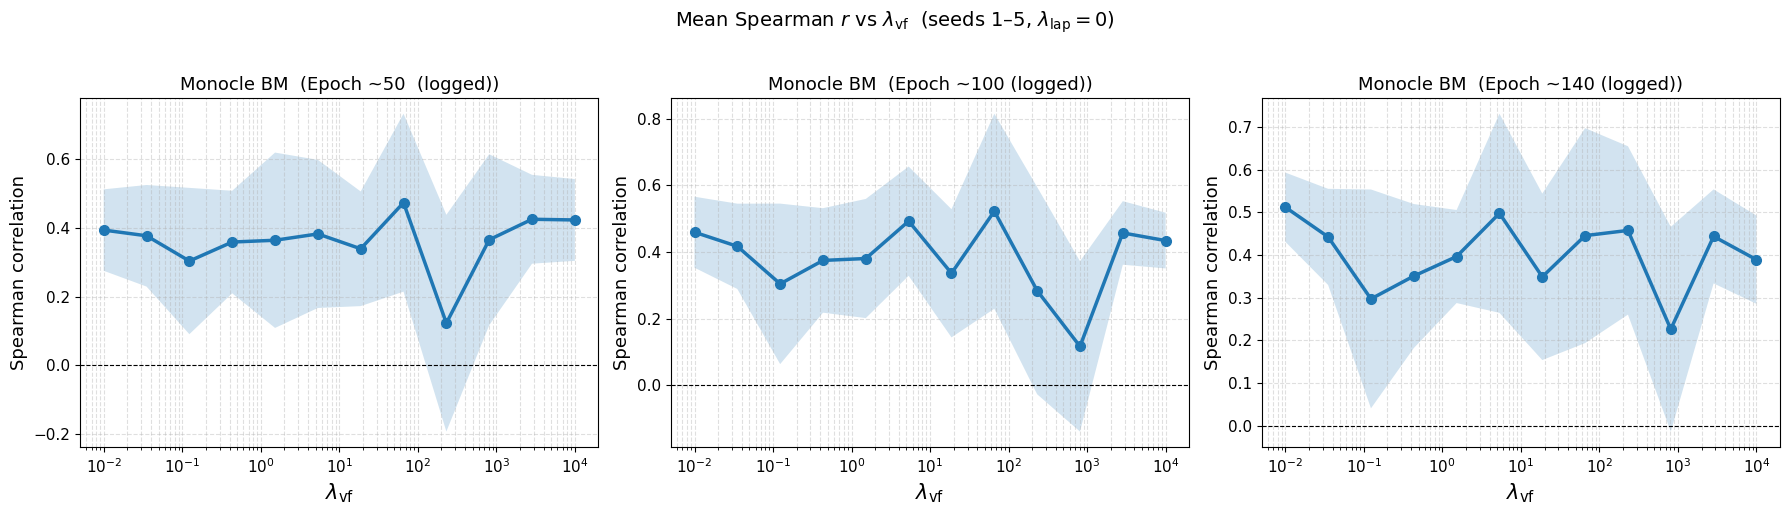

In [13]:
# ---------------------------------------------------------------------------
# Plot 1: Mean ± std across seeds — one panel per epoch checkpoint
# Matches the intended plot_correlation_vs_lambda_vf output
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50  (logged)',  axes[0]),
    ('~100', 'Epoch ~100 (logged)',  axes[1]),
    ('~140', 'Epoch ~140 (logged)',  axes[2]),
]

for label, title, ax in checkpoints:
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7)
    ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
    ax.set_ylabel('Spearman correlation', fontsize=13)
    ax.set_title(f'Monocle BM  ({title})', fontsize=13)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)

plt.suptitle(r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (seeds 1–5, $\lambda_{\mathrm{lap}}=0$)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

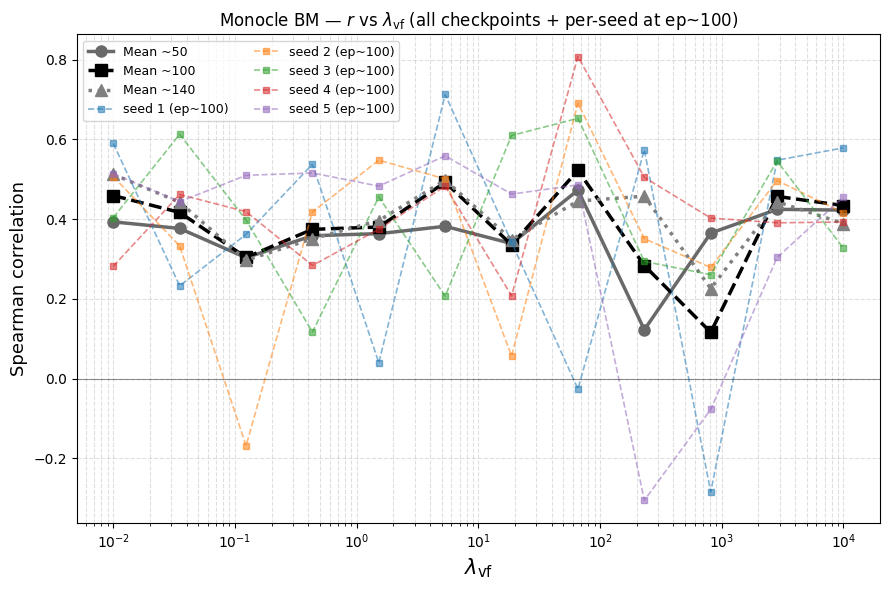

In [6]:
# ---------------------------------------------------------------------------
# Plot 2: Per-seed traces + mean — all three checkpoints overlaid on one plot
# ---------------------------------------------------------------------------

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
seed_labels_all = ['seed 1', 'seed 2', 'seed 3', 'seed 4', 'seed 5']
checkpoint_styles = {'~50': ('o', '-'), '~100': ('s', '--'), '~140': ('^', ':')}

fig, ax = plt.subplots(figsize=(9, 6))

for label, (marker, ls) in checkpoint_styles.items():
    mu = summary[label]['mean']
    ax.semilogx(LAMBDA_VFS, mu, marker=marker, linestyle=ls,
                linewidth=2.5, markersize=8, label=f'Mean {label}',
                color='black' if label == '~100' else ('dimgray' if label == '~50' else 'gray'))

# Individual seeds at epoch ~100
for s_idx, (color, seed_label) in enumerate(zip(seed_colors, seed_labels_all)):
    vals = all_seeds[s_idx, :, EPOCH_IDX['~100']]
    ax.semilogx(LAMBDA_VFS, vals, marker='s', linestyle='--',
                linewidth=1.2, markersize=5, alpha=0.55, color=color, label=f'{seed_label} (ep~100)')

ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title(r'Monocle BM — $r$ vs $\lambda_{\mathrm{vf}}$ (all checkpoints + per-seed at ep~100)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

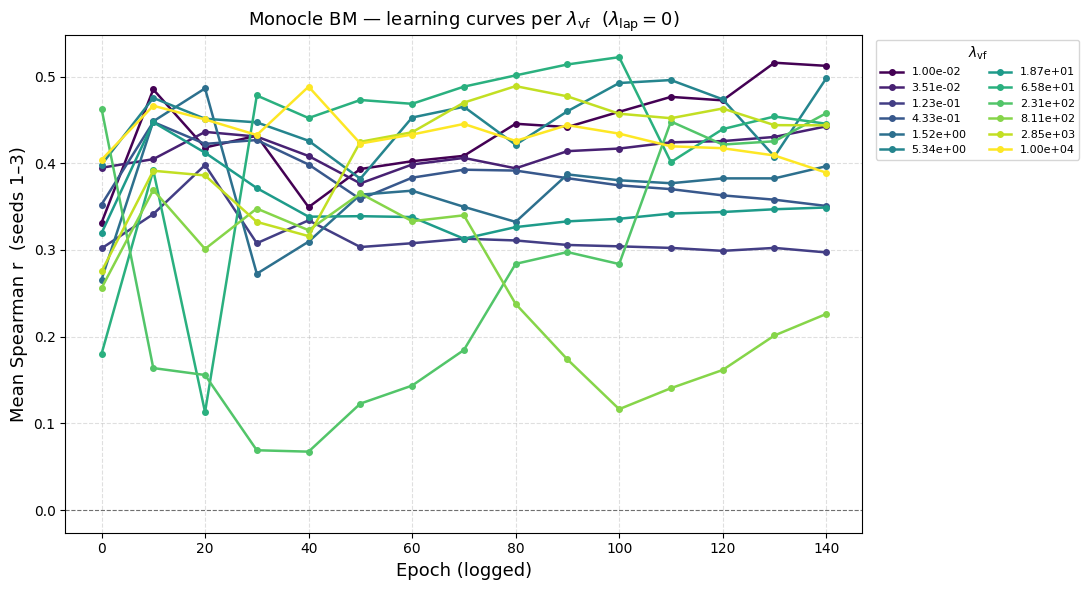

In [7]:
# ---------------------------------------------------------------------------
# Plot 3: Learning curves (r vs epoch) for each λ_vf — mean across seeds
# ---------------------------------------------------------------------------

epochs_arr = np.array(EPOCHS_LOGGED)

# Mean across seeds (nanmean)
mean_curves = np.nanmean(all_seeds, axis=0)  # (12, 15)

cmap = plt.cm.viridis
colors = [cmap(i / 11) for i in range(12)]

fig, ax = plt.subplots(figsize=(11, 6))
for lv_idx in range(12):
    lv_val = LAMBDA_VFS[lv_idx]
    curve = mean_curves[lv_idx]
    ax.plot(epochs_arr, curve, marker='o', markersize=4, linewidth=1.8,
            color=colors[lv_idx], label=f'{lv_val:.2e}')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch (logged)', fontsize=13)
ax.set_ylabel('Mean Spearman r  (seeds 1–3)', fontsize=13)
ax.set_title(r'Monocle BM — learning curves per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=0$)', fontsize=13)
ax.legend(title=r'$\lambda_{\mathrm{vf}}$', fontsize=8, ncol=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

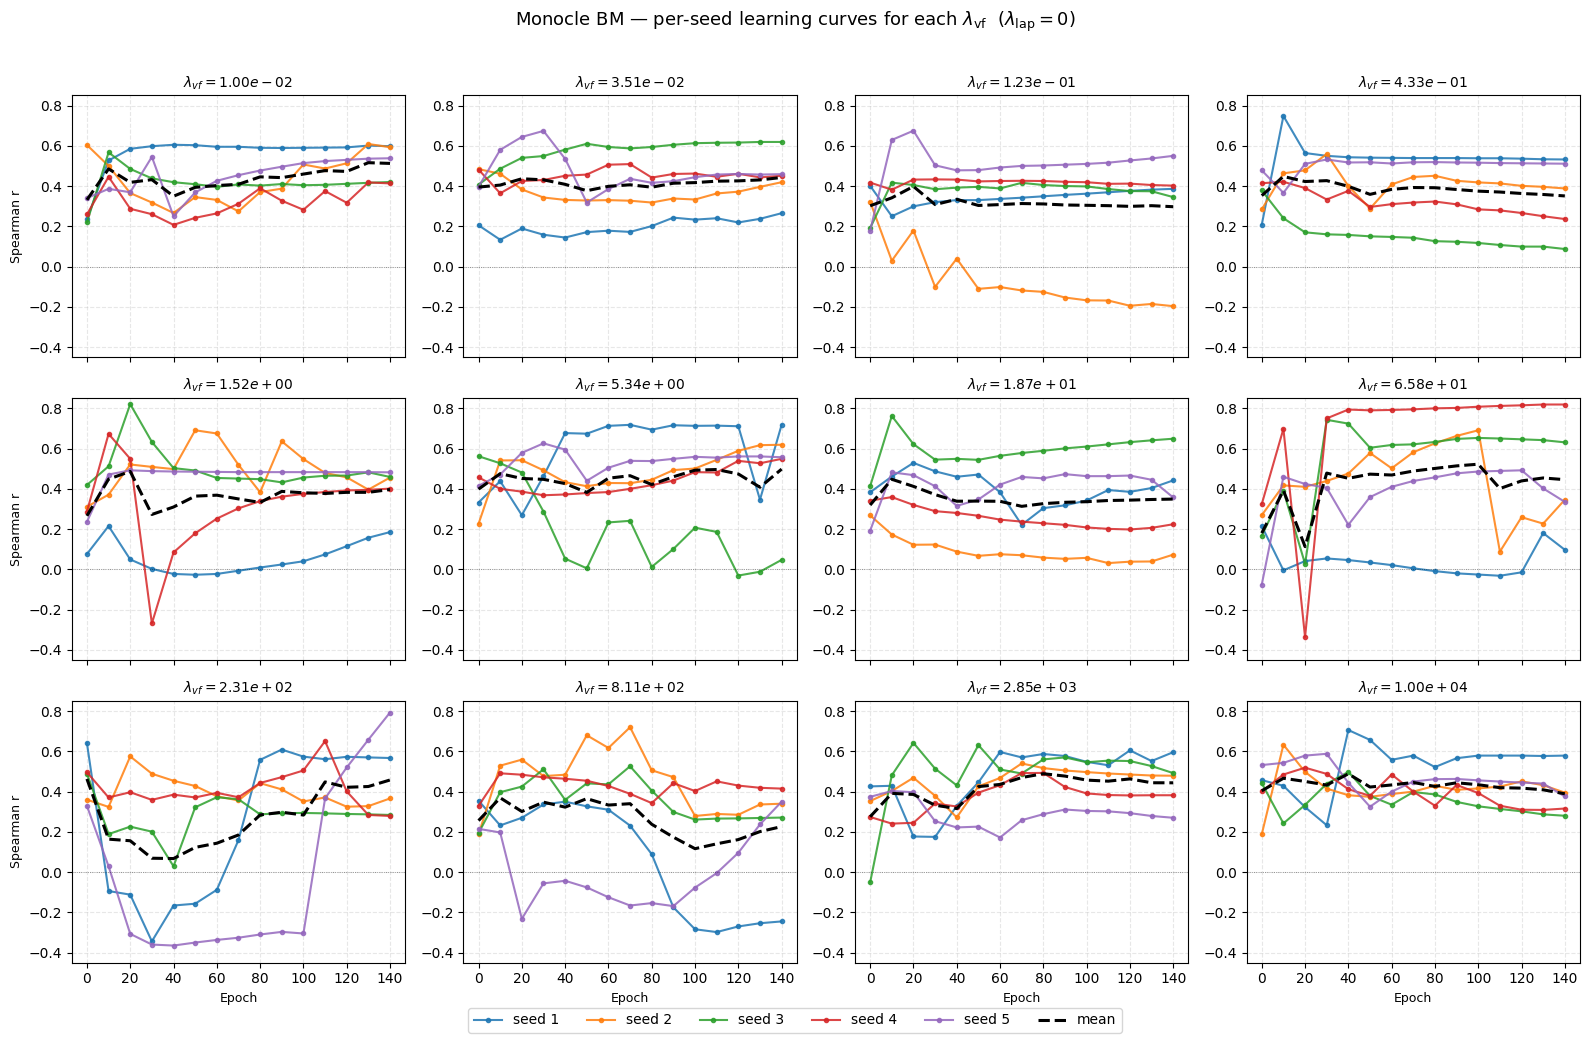

In [8]:
# ---------------------------------------------------------------------------
# Plot 4: Per-seed learning curves (small multiples) for each λ_vf
# ---------------------------------------------------------------------------

n_lv = 12
ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10), sharex=True)

seed_labels = ['seed 1', 'seed 2', 'seed 3', 'seed 4', 'seed 5']
seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for lv_idx, ax in enumerate(axes.flat):
    lv_val = LAMBDA_VFS[lv_idx]
    for s_idx in range(5):
        curve = all_seeds[s_idx, lv_idx, :]
        ax.plot(epochs_arr, curve, marker='o', markersize=3, linewidth=1.5,
                color=seed_colors[s_idx], label=seed_labels[s_idx], alpha=0.85)
    # mean
    ax.plot(epochs_arr, np.nanmean(all_seeds[:, lv_idx, :], axis=0),
            color='black', linewidth=2.2, linestyle='--', label='mean')
    ax.axhline(0, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(rf'$\lambda_{{vf}}={lv_val:.2e}$', fontsize=10)
    ax.set_ylim(-0.45, 0.85)
    ax.grid(True, linestyle='--', alpha=0.3)
    if lv_idx % ncols == 0:
        ax.set_ylabel('Spearman r', fontsize=9)
    if lv_idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Epoch', fontsize=9)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(r'Monocle BM — per-seed learning curves for each $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=0$)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vf_sweep_per_seed_grid.png', dpi=200, bbox_inches='tight')
plt.show()

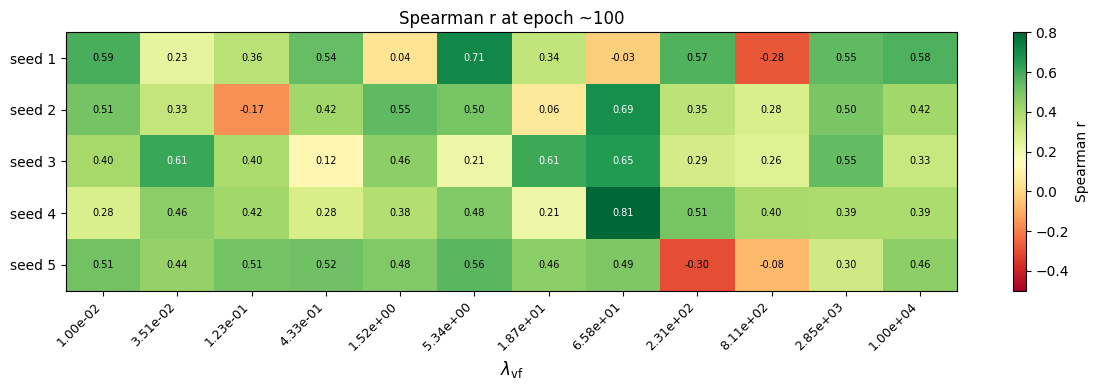

In [11]:
# ---------------------------------------------------------------------------
# Heatmap: r at epoch ~100 for all seeds × all lambda_vfs
# ---------------------------------------------------------------------------

r_ep100 = all_seeds[:, :, EPOCH_IDX['~100']]  # (5, 12)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(r_ep100, aspect='auto', cmap='RdYlGn', vmin=-0.5, vmax=0.8)
ax.set_xticks(range(12))
ax.set_xticklabels([f'{v:.2e}' for v in LAMBDA_VFS], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels(['seed 1', 'seed 2', 'seed 3', 'seed 4', 'seed 5'])
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=12)
ax.set_title('Spearman r at epoch ~100', fontsize=12)
plt.colorbar(im, ax=ax, label='Spearman r')

# Annotate values
for i in range(5):
    for j in range(12):
        val = r_ep100[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(val) < 0.6 else 'white')

plt.tight_layout()
plt.savefig('vf_sweep_heatmap_ep100.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
# ---------------------------------------------------------------------------
# Summary table — best lambda_vf per epoch checkpoint
# ---------------------------------------------------------------------------

print('Best lambda_vf by mean r:\n')
for label in ['~50', '~100', '~140']:
    mu = summary[label]['mean']
    best_idx = np.nanargmax(mu)
    print(f'  Epoch {label:5s}:  lambda_vf = {LAMBDA_VFS[best_idx]:.3e}  '
          f'→  mean r = {mu[best_idx]:.3f}  (std={summary[label]["std"][best_idx]:.3f})')

print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))

Best lambda_vf by mean r:

  Epoch ~50  :  lambda_vf = 6.579e+01  →  mean r = 0.473  (std=0.259)
  Epoch ~100 :  lambda_vf = 6.579e+01  →  mean r = 0.522  (std=0.293)
  Epoch ~140 :  lambda_vf = 1.000e-02  →  mean r = 0.512  (std=0.081)

 lambda_vf  ep50_mean  ep50_std  ep100_mean  ep100_std  ep140_mean  ep140_std
     0.010      0.393     0.118       0.459      0.107       0.512      0.081
     0.035      0.377     0.148       0.417      0.128       0.443      0.113
     0.123      0.303     0.213       0.304      0.241       0.297      0.257
     0.433      0.359     0.149       0.375      0.157       0.351      0.169
     1.520      0.364     0.255       0.380      0.179       0.397      0.109
     5.337      0.382     0.215       0.493      0.164       0.498      0.233
    18.738      0.339     0.167       0.336      0.193       0.349      0.195
    65.793      0.473     0.259       0.522      0.293       0.446      0.252
   231.013      0.123     0.315       0.284      0.311      